In [1]:
import numpy as np
from numpy.linalg import eigh
from scipy.linalg import eigh, expm, svd
import sys
import os
import warnings
warnings.filterwarnings('ignore', category=UserWarning, append = True)


import tenpy
from tenpy.networks.mps import MPS
from tenpy.algorithms import dmrg, tebd
from tenpy.networks.mpo import MPO
from tenpy_toycodes.a_mps import SimpleMPS, init_FM_MPS, init_Neel_MPS
from tenpy_toycodes.b_model import TFIModel
from tenpy_toycodes.d_dmrg import SimpleDMRGEngine, SimpleHeff2, DMRG_tf_ising_finite
from tenpy_toycodes.tfi_exact import finite_gs_energy

import tenpy.linalg.np_conserved as npc
from tenpy.models.tf_ising import TFIChain

import time
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

The bellow is a class constructed for the TFIM which is featured on the TeNPy website

In [ ]:
def QFI(psi, op):
    """
    Calculate the Quantum Fisher Information (QFI) for a given state and operator.
    
    Parameters:
    psi : MPS
        The matrix product state representing the quantum state.
    op : str
        The operator for which to calculate the QFI ('Sigmax' or 'Sigmaz').
        
    Returns:
    float
        The calculated QFI value.
    """
    # Calculate the expectation value of the operator
    expe = np.mean(psi.expectation_value(op))
    
    # Calculate the correlation function
    corr_q2 = psi.correlation_function(op, op, sites1=None, sites2=None)
    
    # Calculate the expectation value of the squared operator
    expectation_q2 = np.mean(corr_q2)
    
    # Calculate QFI using the formula: QFI = 4 * (expectation_q2 - expe^2)
    qfi = 4 * (expectation_q2 - expe**2)
    
    return qfi

def build_Q_MPO(model,  op = 'Sigmax'):
    """
    builds an MPO corresponding to Q = 1/L sum_i op_i
    """
    L = model.lat.N_cells
    Id = model.lat.unit_cell[0].get_op("Id")

    Q = model.lat.unit_cell[0].get_op(op)
        
    W = []
    for i in range(L):
        Wi = np.empty((2, 2), dtype=object)

        Wi[0, 0] = Id
        Wi[1, 1] = Id

        Wi[0, 1] = Q / L
        Wi[1, 0] = None

        W.append(Wi)

    return MPO.from_grids(model.lat.mps_sites(), W, IdL=0, IdR=1)

def calculate_QtQ(op, model_params,   dmrg_tebd_params  ):
    """ Calculates 1/2 < psi | {Q(t), Q} | psi > 
        for psi the ground state of model """

    model_type = model_params.get("model_type", "Ising")
    if model_type == "Ising":
        M = TFIChain(model_params)
    else: 
        raise ValueError("Model type not configured yet")

    #DMRG engine
    psi = MPS.from_lat_product_state(M.lat, [['up']])
    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_tebd_params)
    E0, psi = eng.run()


    # apply phi = Q |psi > Must be careful here because some processes
    # in MPS and MPO by default normalize the output wavefunction
    phi = psi.copy()
    op_MPO = build_Q_MPO(M , op)
    op_MPO.apply(phi, options={'compression_method' : 'SVD'})
    
    # TEBD engine
    phi_t = phi.copy()
    start_time = dmrg_tebd_params.get('start_time',0)
    engine = tebd.TEBDEngine(phi_t, M, dmrg_tebd_params)
    engine.evolved_time = 0

    if start_time > 0 and start_time < 0.05:
        engine.calc_U(2, start_time)
        engine.evolve( 1,   dt = start_time)
        engine.evolved_time = round(engine.evolved_time, 4)
    elif start_time >0:
        initial_steps = int(start_time * 20)
        engine.calc_U(2, start_time/initial_steps )
        engine.evolve(initial_steps,   dt = start_time/initial_steps)
        engine.evolved_time = round(engine.evolved_time, 4)

    times = [engine.evolved_time]
    expec_U = [np.real(phi.overlap(phi_t)* np.exp(1j * E0 * start_time))]  # 1/2 <psi | {Q(t), Q} | psi > = Re[< phi | U | phi > exp(i E_0 t)]
    engine.calc_U(2, dmrg_tebd_params['dt'] )

    for _ in range(dmrg_tebd_params.get('N_times', 1)):

        engine.run()
        t = engine.evolved_time
        times.append(round(t, 4))
        expec_U.append(np.real(phi.overlap(phi_t) * np.exp(1j * E0 * t)))

    return times, expec_U

def calculate_LG_correlator(op, model_params,   dmrg_tebd_params ):
    """Calculates 2 [C(t) - C(0)] - [C(2t) - C(0)] """

    #Calculates C values from 0 to time_end
    times_1, leg_1 = calculate_QtQ(op, model_params,   dmrg_tebd_params  )    #Calculates only the extra C values needed to calculate K

    dmrg_tebd_params['start_time'] = round(times_1[-1] + 2 *dmrg_tebd_params['N_steps'] * dmrg_tebd_params['dt'],4)
    dmrg_tebd_params['N_steps'] = 2 * (dmrg_tebd_params['N_steps'])
    dmrg_tebd_params['N_times'] = int( dmrg_tebd_params['N_times']/2-1)
    
    times_2, leg_2 = calculate_QtQ(op, model_params, dmrg_tebd_params )

    #padding the data lists makes calculating K easier
    times_2 = [item for pair in zip( [-100] * len(times_2), times_2) for item in pair]
    leg_2 = [item for pair in zip(  [-100] * len(leg_2), leg_2) for item in pair]
    
    cor_tot = leg_1 + leg_2

    LG_B_lst = []
    K_lst = []
    # LG_B = 2C(t) - C(2t) - C(0)
    for i in range(len(times_1)):
        LG_B_lst += [cor_tot[i] * 2 - cor_tot[2 * i] - cor_tot[0]]
        K_lst += [cor_tot[i] * 2 - cor_tot[2 * i] ]
        
    return times_1 , LG_B_lst, K_lst 

def calculate_LG_bound(op, model_params,   dmrg_tebd_params ):
    """Calculates the lower bound on the QFI set by the LG correlator QFI > 8 LG_B_Max"""

    dt = dmrg_tebd_params['dt']
    t_max = dmrg_tebd_params['t_max']
    N_steps = dmrg_tebd_params['N_steps']
    N_times = 2 * int(t_max /(2 * dt * N_steps))

    times, LG_B, Kt = calculate_LG_correlator(op, model_params,   dmrg_tebd_params )

    return 8 * np.max(LG_B)



In [28]:
model_params = {
    'J': 1 , 'g': 1.1,  # critical
    'L': 4,
    'bc_MPS': 'finite',
    'model_type' : "Ising",
    'conserve' : None
}

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 4,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 2,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 30  #only an option for calculating the bound
}

print(calculate_LG_bound('Sigmax', model_params,  dmrg_tebd_params = extra_params))

0.08980791736120342


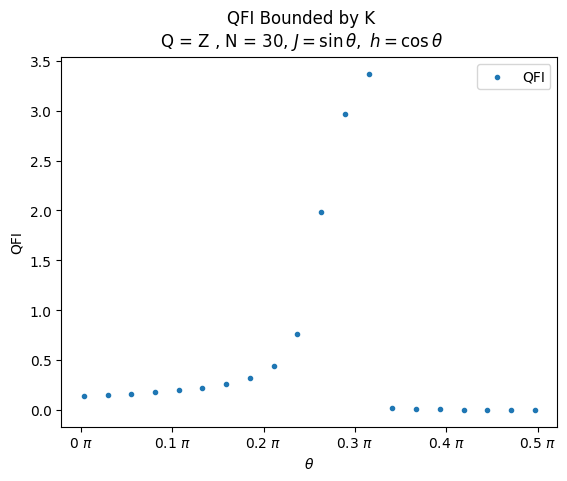

In [ ]:
L = 30
chi_max = 20
op = 'Sigmax'
num_points = 20

dmrg_params = {
        'mixer': True,  # setting this to True helps to escape local minima
        'max_E_err': 1.e-10,
        'trunc_params': {
            'chi_max': chi_max,
            'svd_min': 1.e-10,
        },
        'combine': True
    }

theta_range = np.linspace(.01, np.pi/2- .01, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    M = TFIChain(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up', 'down']], allow_incommensurate= True)
    
    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place
    
    
    #Generate QFI
    QFI_lst += [QFI(psi, op)] #[qfi3]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, QFI_lst, marker = '.', label = "QFI", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()

In [33]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_Ztot_QFI_Bound.png")

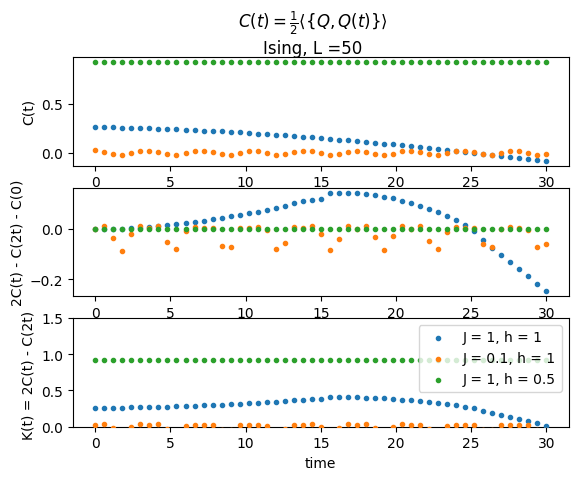

In [19]:
L = 50
chi_max = 30
op = 'Sigmax'
num_points = 50
t_end = 30  
dt = 0.02
Jg_lst = [[1,1],[.1,1],[1,.5]]

fig, ax = plt.subplots(3)

for J, g in Jg_lst: 

    model_params = {
        'J': J , 'g': g, 
        'L': L,
        'bc_MPS': 'finite',
        'model_type' : "Ising",
        'conserve' : None    }
    
    extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': chi_max,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : num_points,
    'dt': dt,'N_steps': 2*int( t_end//(2*dt * num_points)),
    'order': 2, 'start_time' : 0}

    times, Ct = calculate_QtQ('Sigmax', model_params,  dmrg_tebd_params = extra_params)
    ax[0].scatter(times, Ct, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)
    times, LG_correl, Kt = calculate_LG_correlator('Sigmax', model_params,  dmrg_tebd_params = extra_params)
    ax[1].scatter(times, LG_correl, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)
    ax[2].scatter(times, Kt, marker = '.', label = "J = " + str(J) + ", h = " + str(g), zorder = 3)


fig.suptitle("$C(t) = \\frac{1}{2}\\langle \\{Q, Q(t) \\}\\rangle$\nIsing, L =" + str(L))
ax[2].xaxis.set_major_formatter(tck.FormatStrFormatter("%g"))
plt.xlabel("time")
ax[0].set(ylabel = "C(t)")
ax[1].set(ylabel = "2C(t) - C(2t) - C(0)")
ax[2].set(ylabel = "K(t) = 2C(t) - C(2t) ")
ax[2].set_ylim([0,1.5])
plt.legend()

plt.show()

In [22]:
fig.savefig("C:\\Users\\ianro\\Documents\\Research\\Quantum_Metrology_AKLT\\Plots\\TFIM_L50_C_LG_K.png")

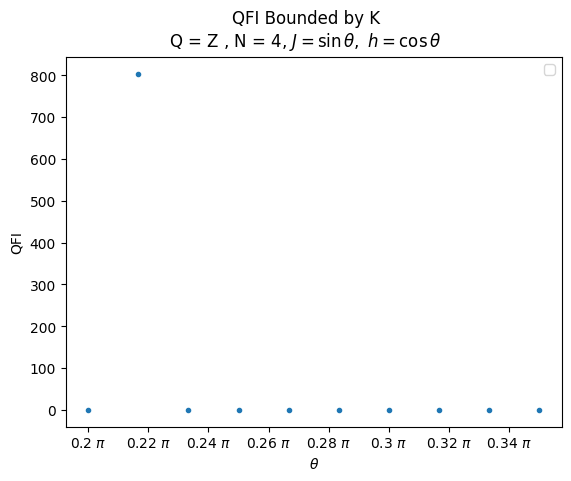

In [31]:
L = 4
chi_max = 30
op = 'Sigmax'
num_points = 10

extra_params = {
    'mixer': None,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-10,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'verbose': False,
    'combine': True,
    'N_times' : 4,  #Only even N_times are used for K,
    'dt': 0.02,'N_steps': 5,
    'order': 2,
    'start_time' : 0  ,
    't_max' : 10  #only an option for calculating the bound
}

theta_range = np.linspace(0.2 * np.pi, 0.35 * np.pi, num_points)

fig, ax = plt.subplots(1)

LG_bound = []
QFI_lst =[]
for theta in theta_range:
    J, g = np.sin(theta), np.cos(theta)

    model_params = {
    'J':  J , 'g':  g,  # critical
    'L': L,
    'bc_MPS': 'finite',
    'conserve' : None}

    LG_bound += [calculate_LG_bound(op, model_params, extra_params )]

#ax.fill_between(theta_range/ np.pi, LG_bound, 4 ,  color = '.7', label = "QFI Bound "  )
ax.scatter(theta_range/ np.pi, LG_bound, marker = '.', label = "", zorder = 3)


fig.suptitle("QFI Bounded by K\nQ = Z , N = " + str(L) + ", $J = \\sin\\theta,~h = \\cos\\theta$")
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
plt.xlabel("$\\theta$")
ax.set(ylabel = "QFI")
#plt.ylim((0.9,1.6))
plt.legend()

plt.show()